# EDA: Exploratory Data Analysis

- [URL: covid_19_deaths.csv](https://docs.google.com/spreadsheets/d/e/2PACX-1vQU0SIALScXx8VXDX7yKNKWWPKE1YjFlWc6VTEVSN45CklWWf-uWmprQIyLtoPDA18tX9cFDr-aQ9S6/pubhtml)

#### Importar librerías

In [55]:
# Librerías disponibles

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Any

In [56]:
# Configuración para los gráficos

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Cargar los datos

In [57]:
# Cargar el archivo covid_19_deaths.csv

df = pd.read_csv('covid_19_deaths.csv')

In [58]:
# Mostrar encabezados del dataset

df.columns.tolist()

['Email',
 'Unnamed: 1',
 'contact.sunky@gmail.com',
 'Unnamed: 3',
 'Unnamed: 4',
 'Unnamed: 5',
 'Unnamed: 6',
 'Unnamed: 7',
 'Unnamed: 8',
 'Unnamed: 9',
 'Unnamed: 10',
 'Unnamed: 11',
 'Unnamed: 12',
 'Unnamed: 13',
 'Unnamed: 14',
 'Unnamed: 15',
 'Unnamed: 16',
 'Unnamed: 17',
 'Unnamed: 18',
 'Unnamed: 19',
 'Unnamed: 20',
 'Unnamed: 21',
 'Unnamed: 22',
 'Unnamed: 23']

💡Los encabezados contienen metadátos o información nula. Los encabezados reales se encuentran en la fila 1.

In [59]:
# Asignar como encabezados los datos de la fila 1

df = pd.read_csv('covid_19_deaths.csv', skiprows=1)

In [60]:
# Comprobar los nuevos encabezados asignadas

df.columns.tolist()

['id',
 'case_in_country',
 'reporting date',
 'Unnamed: 3',
 'summary',
 'location',
 'country',
 'gender',
 'age',
 'symptom_onset',
 'If_onset_approximated',
 'hosp_visit_date',
 'international_traveler',
 'domestic_traveler',
 'exposure_start',
 'exposure_end',
 'traveler',
 'visiting Wuhan',
 'from Wuhan',
 'death',
 'recovered',
 'symptom',
 'source',
 'link']

In [61]:
# Variable con encabezados que no conformarán el análisis.

columns_to_drop = [
    'id', 'Unnamed: 3', 'summary', 'case_in_country', 'If_onset_approximated',
    'traveler', 'visiting Wuhan', 'from Wuhan', 'source', 'link', 'symptom', 'symptom_onset', 'hosp_visit_date'
]

In [62]:
# Eliminar encabezados

df = df.drop(columns=columns_to_drop, axis=0)

In [63]:
# Renombrar encabezado "reporting date a reporting_date"

df.rename(columns={'reporting date': 'reporting_date'}, inplace=True)

In [64]:
# Comprobar encabezados de columna

df.columns.tolist()

['reporting_date',
 'location',
 'country',
 'gender',
 'age',
 'international_traveler',
 'domestic_traveler',
 'exposure_start',
 'exposure_end',
 'death',
 'recovered']

### Primera Exploración

In [65]:
# Mostrar 5 primeras filas

df.head()

,reporting_date,location,country,gender,age,international_traveler,domestic_traveler,exposure_start,exposure_end,death,recovered
0,1/20/2020,"Shenzhen, Guangdong",China,male,66.0,NaN,NaN,12/29/2019,4/1/2020,0,0
1,1/20/2020,Shanghai,China,female,56.0,NaN,NaN,NaN,12/1/2020,0,0
2,1/21/2020,Zhejiang,China,male,46.0,NaN,NaN,NaN,3/1/2020,0,0
3,1/21/2020,Tianjin,China,female,60.0,NaN,NaN,NaN,NaN,0,0
4,1/21/2020,Tianjin,China,male,58.0,NaN,NaN,NaN,NaN,0,0


In [66]:
# Dimensiones del dataset

df.shape

(3397, 11)

In [67]:
# Información general del dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3397 entries, 0 to 3396
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   reporting_date          3396 non-null   str    
 1   location                3167 non-null   str    
 2   country                 3234 non-null   str    
 3   gender                  1685 non-null   str    
 4   age                     1507 non-null   float64
 5   international_traveler  826 non-null    float64
 6   domestic_traveler       802 non-null    float64
 7   exposure_start          194 non-null    str    
 8   exposure_end            488 non-null    str    
 9   death                   1619 non-null   str    
 10  recovered               1606 non-null   str    
dtypes: float64(3), str(8)
memory usage: 292.1 KB


### Estadística Descriptiva

In [68]:
# Descripción de columnas númericas

df.describe()

,age,international_traveler,domestic_traveler
count,1507.000000,826.000000,802.000000
mean,51.040312,0.337772,0.127182
std,18.813253,0.473237,0.333385
min,0.250000,0.000000,0.000000
25%,36.000000,0.000000,0.000000
50%,54.000000,0.000000,0.000000
75%,65.000000,1.000000,0.000000
max,96.000000,1.000000,1.000000


In [69]:
# Descripción de columnas que incluyen texto

df.describe(include=['object', 'string'])

,reporting_date,location,country,gender,exposure_start,exposure_end,death,recovered
count,3396,3167,3234,1685,194,488,1619,1606
unique,57,240,38,3,48,65,24,36
top,12/3/2020,Washington,USA,male,2/26/2020,2/13/2020,0,0
freq,436,472,1768,961,26,45,1536,1423


### Limpieza de Datos

In [70]:
# Identificar valores faltantes (Missing Values)

df.isnull().sum()

reporting_date               1
location                   230
country                    163
gender                    1712
age                       1890
international_traveler    2571
domestic_traveler         2595
exposure_start            3203
exposure_end              2909
death                     1778
recovered                 1791
dtype: int64

In [71]:
# Asignar e imprimir porcentaje de valores faltantes

missing_percent = (df.isnull().sum() / len(df)) * 100
print(f'% de valores faltantes:\n{missing_percent}')

% de valores faltantes:
reporting_date             0.029438
location                   6.770680
country                    4.798351
gender                    50.397409
age                       55.637327
international_traveler    75.684427
domestic_traveler         76.390933
exposure_start            94.289079
exposure_end              85.634383
death                     52.340300
recovered                 52.722991
dtype: float64


💡Dado que el dataset tiene mucha información faltante en variables clave, se determina hacer un balance entre calidad y cantidad de datos:
- Usar columnas con >70% datos completos y filas con >80% completitud.

In [72]:
# Seleccionar columnas útiles (menos del 70% faltantes) e imprimir

cols_utiles = missing_percent[missing_percent < 70].index.tolist()
print(f'Columnas útiles: {cols_utiles}')

Columnas útiles: ['reporting_date', 'location', 'country', 'gender', 'age', 'death', 'recovered']


In [73]:
# Crear subdataset con esas columnas

df_subset = df[cols_utiles]

In [74]:
# Filtrar filas con al menos 80% de datos en esas columnas

completitud_subset = (df_subset.notnull().sum(axis=1) / len(cols_utiles)) * 100
df_analisis = df_subset[completitud_subset >= 80]

print(f'  Filas: {len(df_analisis)} de {len(df)} ({len(df_analisis)/len(df)*100:.1f}%)')

  Filas: 1296 de 3397 (38.2%)


In [75]:
# Analisis exploratorio

# df_analisis.head()
# df_analisis.shape
# df_analisis.info()
# df_analisis.describe()
# df_analisis.describe(include=['object', 'string'])
# df_analisis.isnull().sum()

print(f'  Columnas: {df_analisis.columns.tolist()}')

  Columnas: ['reporting_date', 'location', 'country', 'gender', 'age', 'death', 'recovered']


In [76]:
# Porcentaje de datos faltantes por columna

missing_percent_analisis = (df_analisis.isnull().sum() / len(df)) * 100
print(missing_percent_analisis[missing_percent_analisis > 0])

gender       1.030321
age          3.679717
recovered    0.353253
dtype: float64


In [77]:
# Imputar age con la mediana

median_age = df_analisis['age'].median()
df_analisis['age'] = df_analisis['age'].fillna(median_age)

In [78]:
# Imputar gender con la moda

mode_gender = df_analisis['gender'].mode()[0]
df_analisis['gender'] = df_analisis['gender'].fillna(mode_gender)

In [79]:
# Calcular filas con valores faltantes

df_analisis.isnull().sum()

reporting_date     0
location           0
country            0
gender             0
age                0
death              0
recovered         12
dtype: int64

In [80]:
# Eliminar filas con valores faltantes

df_analisis = df_analisis.dropna()

In [81]:
# Comprobar nuevamente

df_analisis.isnull().sum()

reporting_date    0
location          0
country           0
gender            0
age               0
death             0
recovered         0
dtype: int64

In [82]:
# Renombrar columna death a "death_confirmation" para mayor claridad

df_analisis = df_analisis.rename(columns={
    'death': 'death_confirmation',
})

# Ver los nombres nuevos de las columnas

print('Columnas después de renombrar:')
print(df_analisis.columns.tolist())
df_analisis.head()

Columnas después de renombrar:
['reporting_date', 'location', 'country', 'gender', 'age', 'death_confirmation', 'recovered']


,reporting_date,location,country,gender,age,death_confirmation,recovered
0,1/20/2020,"Shenzhen, Guangdong",China,male,66.0,0,0
1,1/20/2020,Shanghai,China,female,56.0,0,0
2,1/21/2020,Zhejiang,China,male,46.0,0,0
3,1/21/2020,Tianjin,China,female,60.0,0,0
4,1/21/2020,Tianjin,China,male,58.0,0,0


In [83]:
# Normalizar tipo y valor de variable: "death_confirmation"

df_analisis['death_confirmation'] = df_analisis['death_confirmation'].astype(str).apply(
    lambda x: 0 if x == '0' else 1
)

# Verificar resultado
print(f'Tipo de dato: {df_analisis['death_confirmation'].dtype}')
print(df_analisis['death_confirmation'].value_counts())

Tipo de dato: int64
death_confirmation
0    1219
1      65
Name: count, dtype: int64


### Análisis Univariado

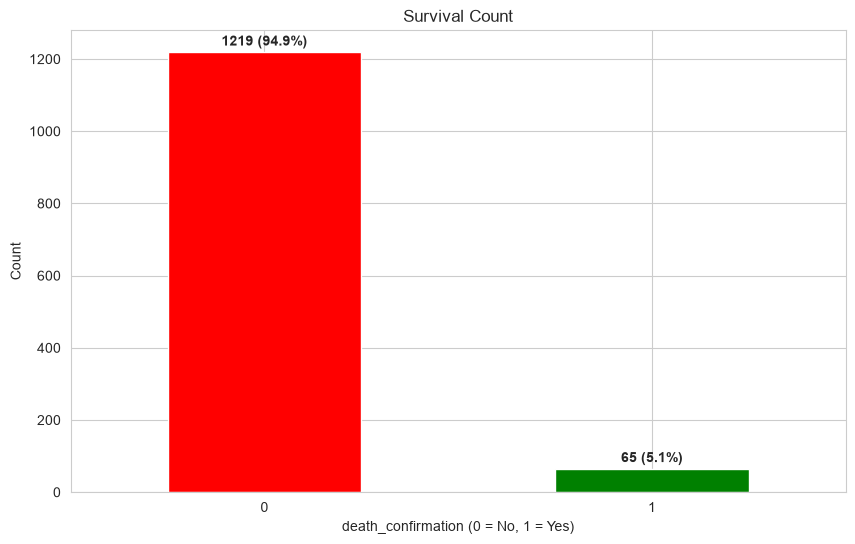

In [84]:
# Variable categórica: "death_confirmation"

counts = df_analisis['death_confirmation'].value_counts()
ax = counts.plot(kind='bar', color=['red', 'green'])
plt.title('Survival Count') # type: ignore
plt.xlabel('death_confirmation (0 = No, 1 = Yes)') # type: ignore
plt.ylabel('Count') # type: ignore
plt.xticks(rotation=0) # type: ignore

# Agregar valores sobre las barras
for i, (index, value) in enumerate(counts.items()):
    # Añadir etiqueta con el valor
    ax.text(i, value + 10, f'{value} ({value/len(df_analisis)*100:.1f}%)', # type: ignore
            ha='center', va='bottom', fontweight='bold')
    
plt.show() # type: ignore

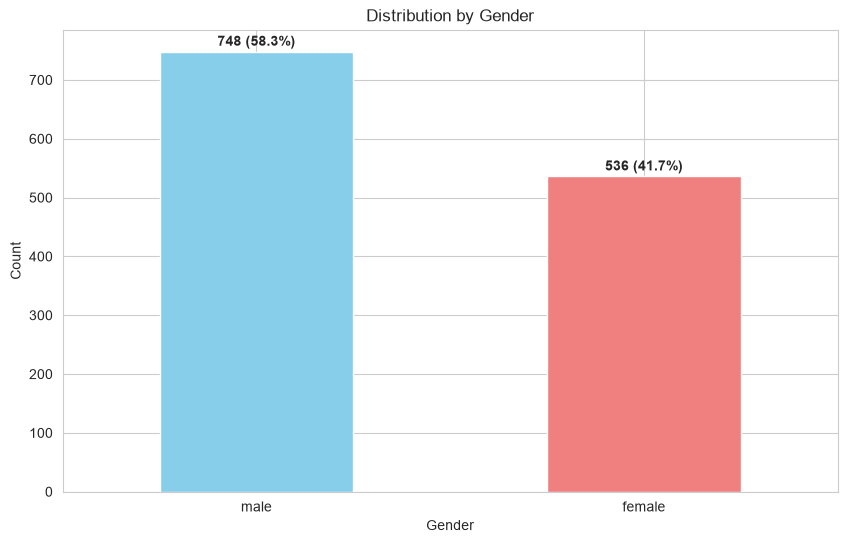

In [85]:
# Variable categórica: "gender"

counts_gender = df_analisis['gender'].value_counts()
ax = counts_gender.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Distribution by Gender') # type: ignore
plt.xlabel('Gender') # type: ignore
plt.ylabel('Count') # type: ignore
plt.xticks(rotation=0) # type: ignore

# Agregar valores sobre las barras
total = len(df_analisis)
for i, (index, value) in enumerate(counts_gender.items()):
    percentage = (value / total) * 100
    ax.text(i, value + 5, f'{value} ({percentage:.1f}%)',  # type: ignore
            ha='center', va='bottom', fontweight='bold')
    
plt.show() # type: ignore

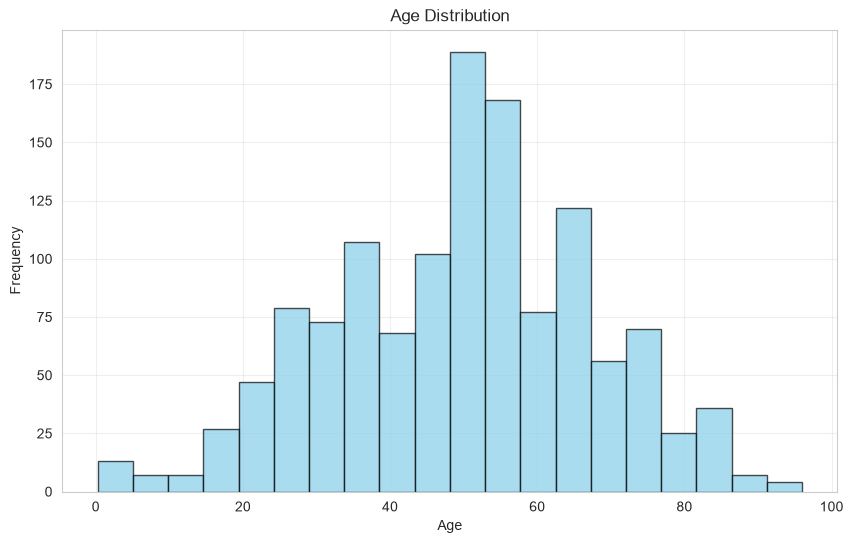

In [86]:
# Variable numérica "age"

plt.figure(figsize=(10, 6)) # type: ignore
plt.hist(df_analisis['age'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='skyblue') # type: ignore
plt.title('Age Distribution') # type: ignore
plt.xlabel('Age') # type: ignore
plt.ylabel('Frequency') # type: ignore
plt.grid(True, alpha=0.3) # type: ignore

plt.show() # type: ignore

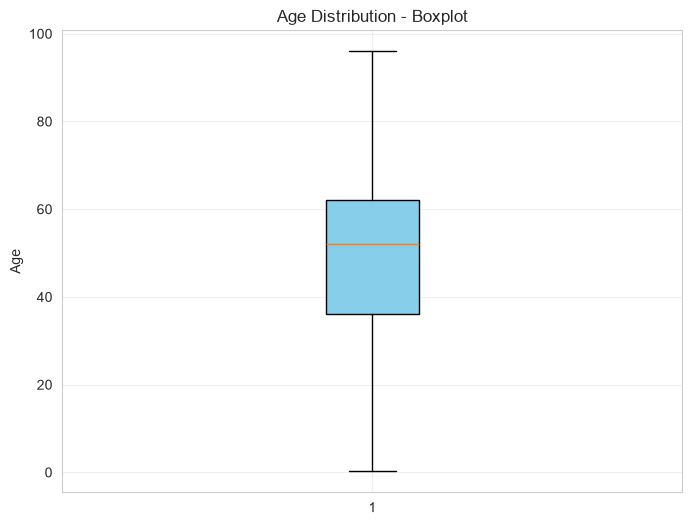

In [87]:
# Boxplot de edad "age"

plt.figure(figsize=(8, 6)) # type: ignore
plt.boxplot(df_analisis['age'].dropna(), orientation='vertical', patch_artist=True,
            boxprops=dict(facecolor='skyblue'),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=6))
plt.title('Age Distribution - Boxplot') # type: ignore
plt.ylabel('Age') # type: ignore
plt.grid(True, alpha=0.3) # type: ignore
plt.show() # type: ignore

### Análisis Bivariado

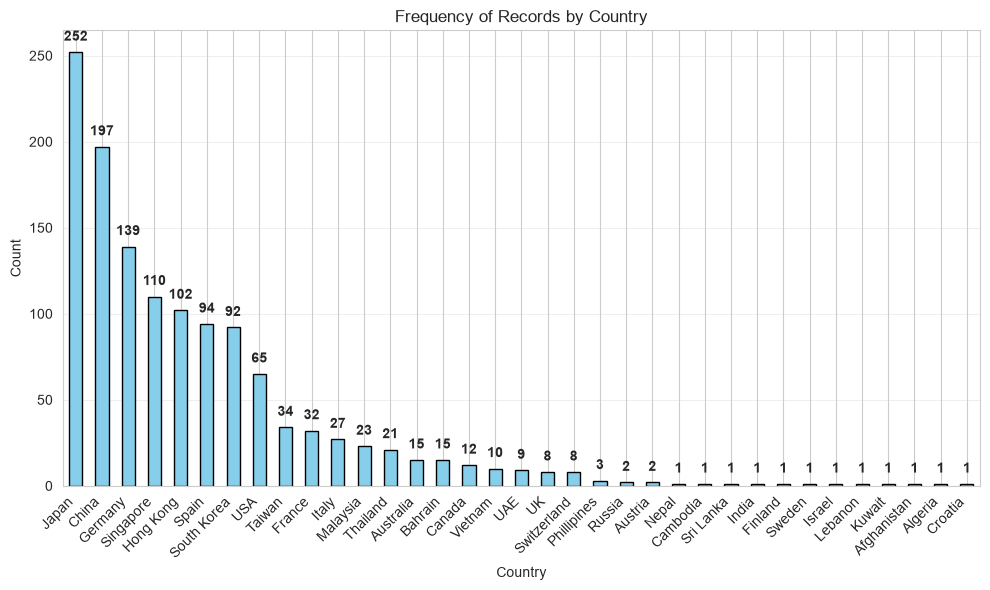

In [88]:
# Conteo de registros por país

country_counts = df_analisis['country'].value_counts()

plt.figure(figsize=(10, 6)) # type: ignore
country_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Frequency of Records by Country') # type: ignore
plt.xlabel('Country') # type: ignore
plt.ylabel('Count') # type: ignore
plt.xticks(rotation=45, ha='right') # type: ignore
plt.grid(True, alpha=0.3, axis='y') # type: ignore

# Agregar valores sobre las barras
for i, (country, count) in enumerate(country_counts.items()):
    plt.text(i, count + 5, str(count), ha='center', va='bottom', fontweight='bold') # type: ignore

plt.tight_layout()
plt.show() # type: ignore

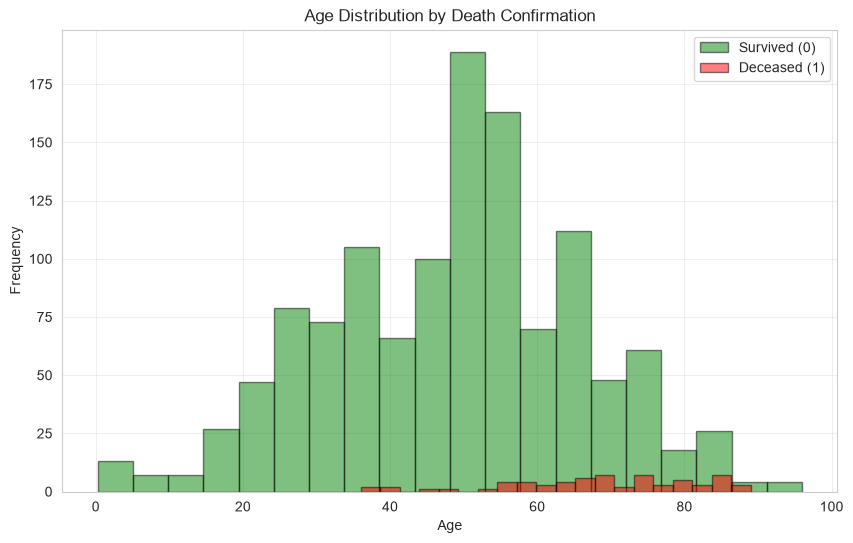

In [89]:
plt.figure(figsize=(10, 6)) # type: ignore

# Separar datos
ages_survived = df_analisis[df_analisis['death_confirmation'] == 0]['age'].dropna()
ages_deceased = df_analisis[df_analisis['death_confirmation'] == 1]['age'].dropna()

# Histogramas
plt.hist(ages_survived, bins=20, alpha=0.5, label='Survived (0)', color='green', edgecolor='black') # type: ignore
plt.hist(ages_deceased, bins=20, alpha=0.5, label='Deceased (1)', color='red', edgecolor='black') # type: ignore

plt.title('Age Distribution by Death Confirmation') # type: ignore
plt.xlabel('Age') # type: ignore
plt.ylabel('Frequency') # type: ignore
plt.legend() # type: ignore
plt.grid(True, alpha=0.3) # type: ignore
plt.show() # type: ignore

### Análisis Multivariado

In [90]:
# Seleccionar solo columnas numéricas

numeric_df = df_analisis.select_dtypes(include=[np.number])
print('=== COLUMNAS NUMÉRICAS DISPONIBLES ===')
print(numeric_df.columns.tolist())
print(f'\nShape: {numeric_df.shape}')

# Calcular matriz de correlación

correlation = numeric_df.corr()
print('\n=== MATRIZ DE CORRELACIÓN ===')
print(correlation.round(3))

=== COLUMNAS NUMÉRICAS DISPONIBLES ===
['age', 'death_confirmation']

Shape: (1284, 2)

=== MATRIZ DE CORRELACIÓN ===
                     age  death_confirmation
age                 1.00                0.25
death_confirmation  0.25                1.00


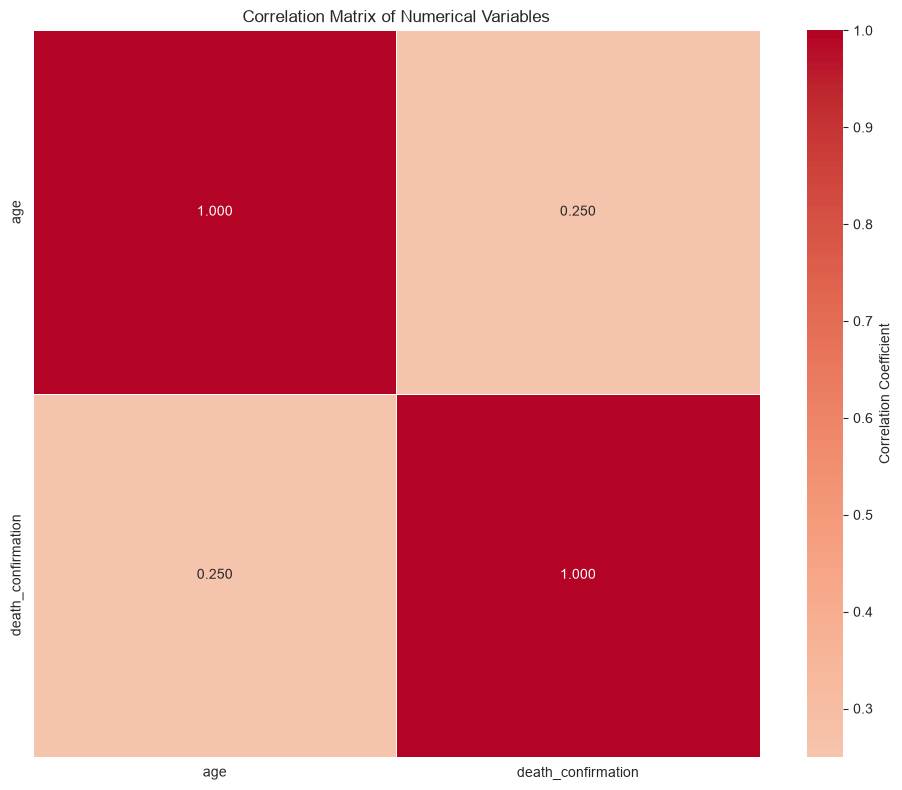

In [91]:
# Mapa de calor de correlaciones
plt.figure(figsize=(10, 8)) # type: ignore
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, # type: ignore 
            fmt='.3f', square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Numerical Variables') # type: ignore
plt.tight_layout()
plt.show() # type: ignore

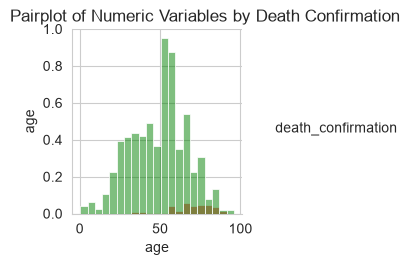

In [92]:
# Pairplot para visualizar relaciones entre variables numéricas
# hue='death_confirmation' colorea los puntos según estado de muerte
# palette={0: 'green', 1: 'red'} define: 0=sobrevivió (verde), 1=falleció (rojo)
# Este gráfico puede tardar un poco porque crea muchas visualizaciones

sns.pairplot(numeric_df, hue='death_confirmation', 
             palette={0: 'green', 1: 'red'},
             diag_kind='hist', 
             plot_kws={'alpha': 0.6, 's': 20})
plt.suptitle('Pairplot of Numeric Variables by Death Confirmation', y=1.02) # type: ignore
plt.show() # type: ignore

### Feature Engineering Básico

In [93]:
# Crear grupos de edad

df_analisis['age_group'] = pd.cut(df_analisis['age'], 
                                   bins=[0, 18, 40, 60, 80, 120], 
                                   labels=['0-18', '19-40', '41-60', '61-80', '80+'])

print("=== AGE GROUP ===")
print(df_analisis['age_group'].value_counts())
print(f"\nMortalidad por grupo etario:")
print(df_analisis.groupby('age_group')['death_confirmation'].mean() * 100)

=== AGE GROUP ===
age_group
41-60    549
19-40    344
61-80    296
80+       50
0-18      45
Name: count, dtype: int64

Mortalidad por grupo etario:
age_group
0-18      0.000000
19-40     0.872093
41-60     2.367942
61-80    11.486486
80+      30.000000
Name: death_confirmation, dtype: float64


In [94]:
# Crear rango etario con más categorías

df_analisis['rango_etario'] = pd.cut(df_analisis['age'], 
                                      bins=[0, 12, 18, 30, 45, 60, 75, 120], 
                                      labels=['0-12', '13-18', '19-30', '31-45', '46-60', '61-75', '75+'])

print("\n=== RANGO ETARIO (detallado) ===")
print(df_analisis['rango_etario'].value_counts())
print(f"\nMortalidad por rango etario:")
print(df_analisis.groupby('rango_etario')['death_confirmation'].mean() * 100)


=== RANGO ETARIO (detallado) ===
rango_etario
46-60    441
31-45    288
61-75    270
19-30    164
75+       76
0-12      25
13-18     20
Name: count, dtype: int64

Mortalidad por rango etario:
rango_etario
0-12      0.000000
13-18     0.000000
19-30     0.000000
31-45     1.736111
46-60     2.494331
61-75    10.370370
75+      27.631579
Name: death_confirmation, dtype: float64


In [95]:
# Asegurar que reporting_date es datetime

df_analisis['reporting_date'] = pd.to_datetime(df_analisis['reporting_date'])

# Extraer mes
df_analisis['month'] = df_analisis['reporting_date'].dt.month

# Crear estación del año
def get_season(month): # type: ignore
    if month in [12, 1, 2]:
        return 'Invierno'
    elif month in [3, 4, 5]:
        return 'Primavera'
    elif month in [6, 7, 8]:
        return 'Verano'
    else:
        return 'Otoño'

df_analisis['season'] = df_analisis['month'].apply(get_season) # type: ignore

print("\n=== ESTACIONALIDAD ===")
print("Distribución por estación:")
print(df_analisis['season'].value_counts())
print(f"\nMortalidad por estación:")
print(df_analisis.groupby('season')['death_confirmation'].mean() * 100)

print("\nDistribución por mes:")
print(df_analisis['month'].value_counts().sort_index())


=== ESTACIONALIDAD ===
Distribución por estación:
season
Invierno     986
Primavera    158
Verano        87
Otoño         53
Name: count, dtype: int64

Mortalidad por estación:
season
Invierno     6.490872
Otoño        0.000000
Primavera    0.632911
Verano       0.000000
Name: death_confirmation, dtype: float64

Distribución por mes:
month
1     388
2     593
3      55
4      52
5      51
6      48
7      18
8      21
9      23
10     18
11     12
12      5
Name: count, dtype: int64


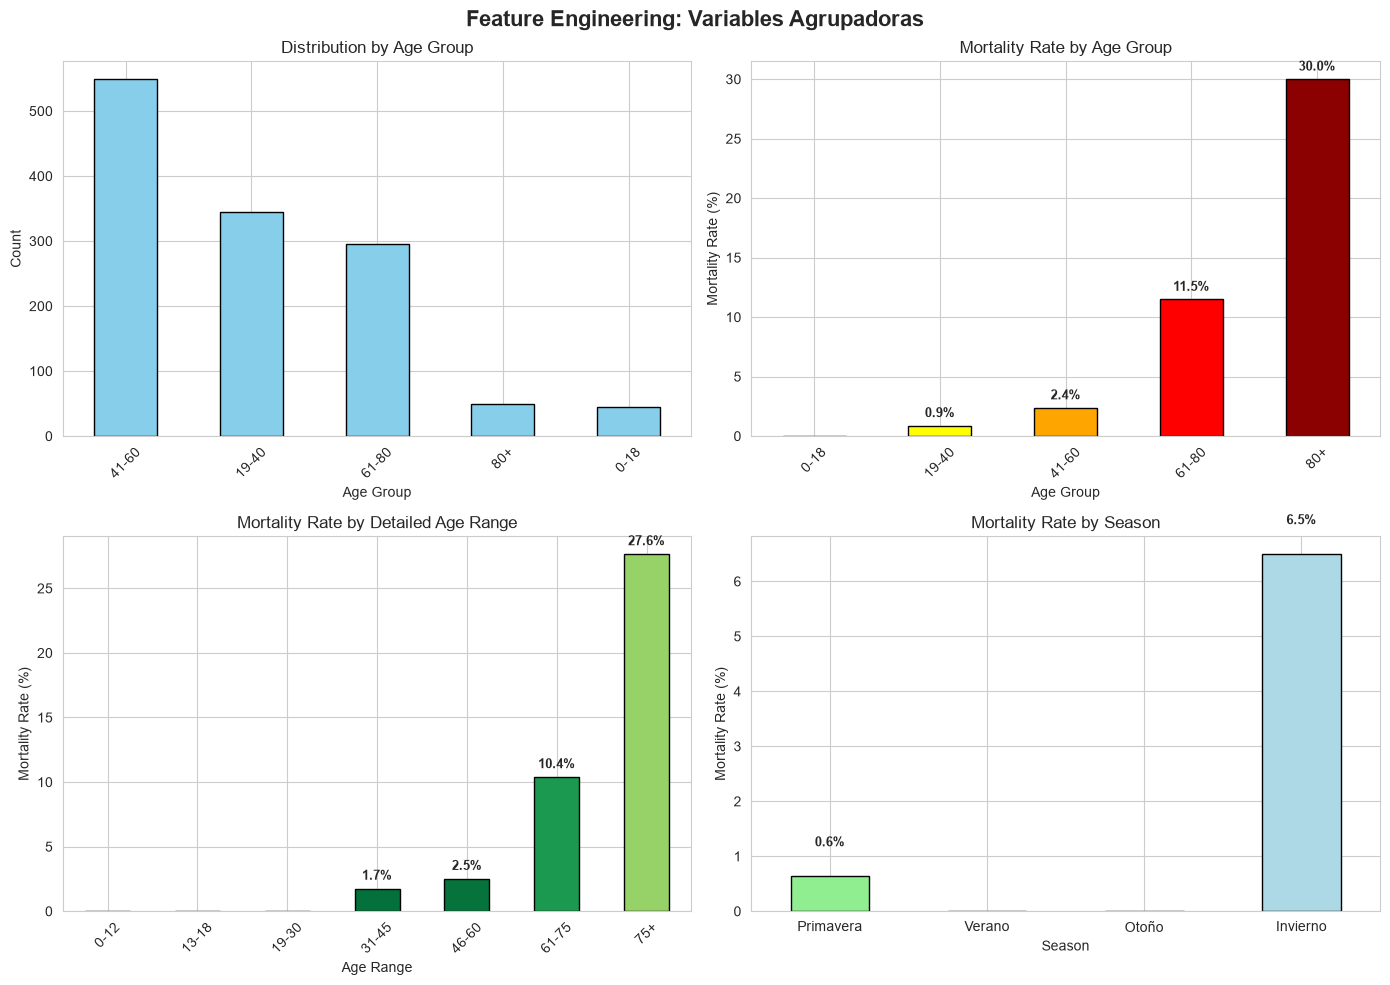

In [96]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Engineering: Variables Agrupadoras', fontsize=16, fontweight='bold') # type: ignore

# 1. Age Group - Distribución y Mortalidad
ax1 = axes[0, 0]
age_group_counts = df_analisis['age_group'].value_counts()
age_group_counts.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Distribution by Age Group')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Count')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

ax2 = axes[0, 1]
mortality_age = df_analisis.groupby('age_group')['death_confirmation'].mean() * 100
mortality_age.plot(kind='bar', ax=ax2, color=['green', 'yellow', 'orange', 'red', 'darkred'], edgecolor='black')
ax2.set_title('Mortality Rate by Age Group')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Mortality Rate (%)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)

# 2. Rango Etario (detallado) - Mortalidad
ax3 = axes[1, 0]
mortality_rango = df_analisis.groupby('rango_etario')['death_confirmation'].mean() * 100
colors_rango = plt.cm.RdYlGn_r(mortality_rango.values / 100) # type: ignore
mortality_rango.plot(kind='bar', ax=ax3, color=colors_rango, edgecolor='black')
ax3.set_title('Mortality Rate by Detailed Age Range')
ax3.set_xlabel('Age Range')
ax3.set_ylabel('Mortality Rate (%)')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)

# 3. Estacionalidad - Mortalidad
ax4 = axes[1, 1]
mortality_season = df_analisis.groupby('season')['death_confirmation'].mean() * 100
season_order = ['Primavera', 'Verano', 'Otoño', 'Invierno']
mortality_season = mortality_season.reindex(season_order)
colors_season = {'Primavera': 'lightgreen', 'Verano': 'gold', 'Otoño': 'orange', 'Invierno': 'lightblue'}
mortality_season.plot(kind='bar', ax=ax4, color=[colors_season[s] for s in mortality_season.index], edgecolor='black')
ax4.set_title('Mortality Rate by Season')
ax4.set_xlabel('Season')
ax4.set_ylabel('Mortality Rate (%)')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)

# Agregar valores sobre las barras
for ax in [ax2, ax3, ax4]:
    for i, bar in enumerate(ax.patches):
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show() # type: ignore